# Notebook 1 — Preprocesamiento y Exploración de Datos
### Tecnologías Emergentes (ISO46B) — Material complementario de comprensión conceptual

**Objetivo:** entender el flujo completo de preprocesamiento y exploración de datos (EDA) que precede a cualquier modelo de Machine Learning o Deep Learning — exploración, detección de atípicos, imputación de faltantes, codificación de categóricas, escalado y partición train/test — con visualizaciones en cada paso.

> Este notebook usa datasets estándar de la comunidad de ML para que puedas ejecutarlo sin depender de conexión a fuentes externas ni de descargas adicionales.


## 0. Configuración inicial

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga de datos

Usamos el dataset **Wine** de `scikit-learn`: 178 muestras de vino de 3 cultivares distintos, descritas por 13 características químicas (alcohol, ácido málico, magnesio, etc.). Es un problema de **clasificación multiclase**, ideal para practicar EDA porque las variables tienen escalas muy distintas entre sí (ej. `magnesium` en decenas vs `hue` en unidades).

In [ ]:
datos = load_wine()
df = pd.DataFrame(datos.data, columns=datos.feature_names)
df["clase"] = datos.target
df["clase_nombre"] = df["clase"].map(dict(enumerate(datos.target_names)))

print(f"Forma del dataset: {df.shape}")
df.head()

Forma del dataset: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase,clase_nombre
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Exploración inicial

Antes de graficar nada, conviene responder tres preguntas: ¿qué tipos de dato tengo?, ¿hay valores faltantes?, ¿las clases están balanceadas?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  clase

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


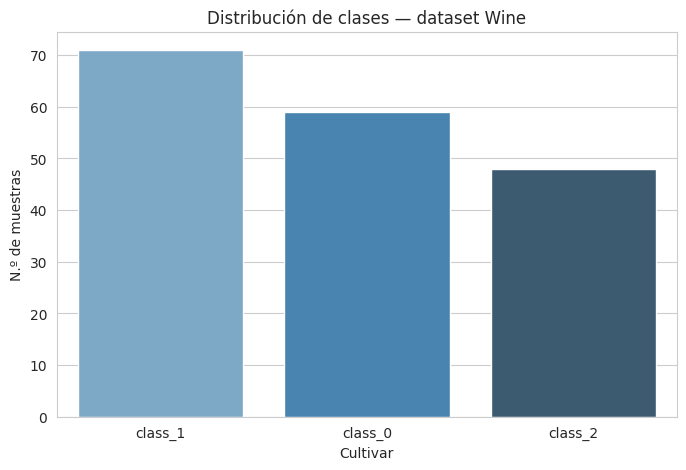

clase_nombre
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [ ]:
conteo_clases = df["clase_nombre"].value_counts()

plt.figure()
sns.barplot(x=conteo_clases.index, y=conteo_clases.values, hue=conteo_clases.index,
            palette="Blues_d", legend=False)
plt.title("Distribución de clases — dataset Wine")
plt.ylabel("N.º de muestras")
plt.xlabel("Cultivar")
plt.show()

print(conteo_clases)

**Lectura del gráfico:** las clases están razonablemente balanceadas (no hay una clase con 5 muestras y otra con 500). Esto importa porque un desbalance fuerte obligaría a usar técnicas especiales (sobremuestreo, ponderación de clases, etc.) antes de entrenar cualquier modelo.

## 3. Visualización exploratoria (EDA)

### 3.1 Distribución de variables individuales

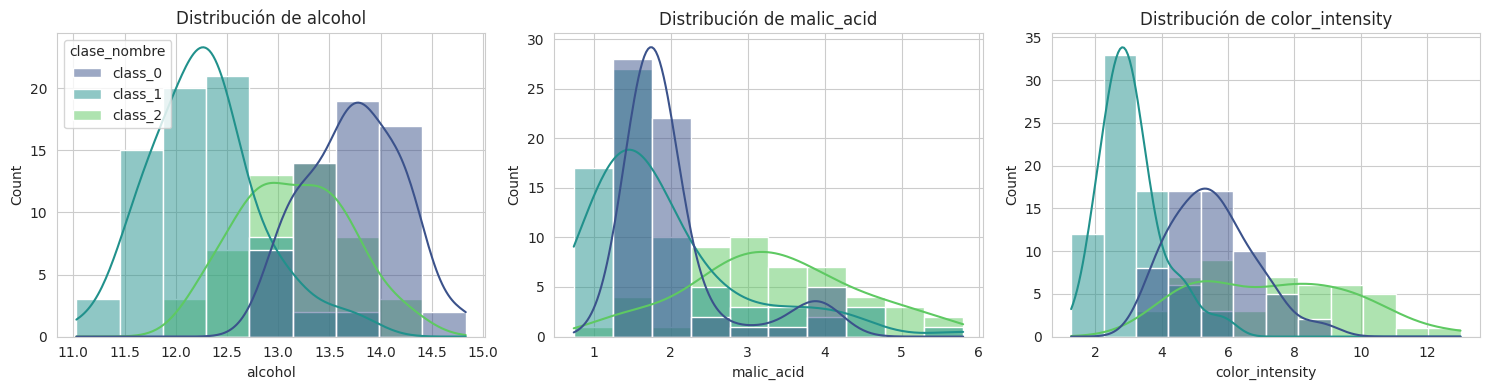

In [ ]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(ejes, ["alcohol", "malic_acid", "color_intensity"]):
    sns.histplot(data=df, x=col, hue="clase_nombre", kde=True, ax=ax, palette="viridis", legend=(col=="alcohol"))
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

### 3.2 Relación entre variables — matriz de correlación

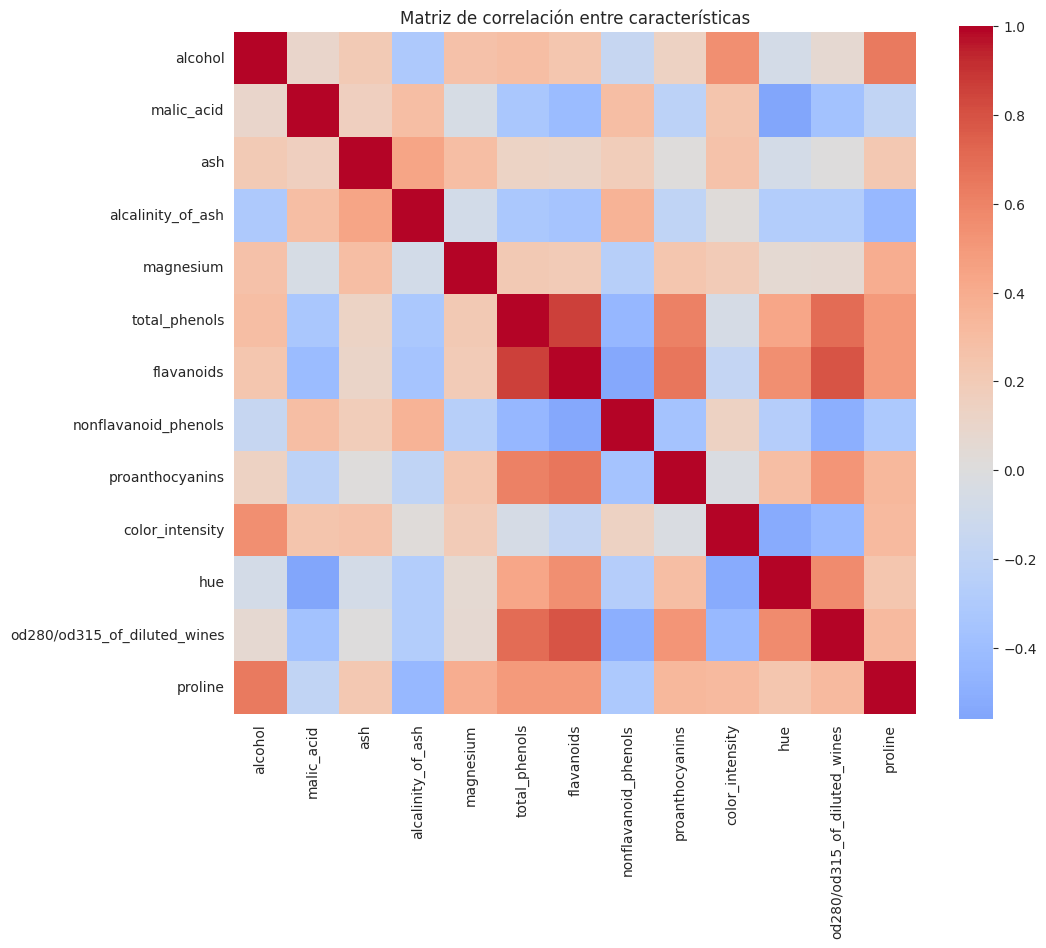

In [ ]:
plt.figure(figsize=(11, 9))
correlacion = df[datos.feature_names].corr()
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Matriz de correlación entre características")
plt.show()

**Lectura:** colores intensos (rojo o azul) indican variables fuertemente correlacionadas. Por ejemplo, `flavanoids` y `total_phenols` suelen mostrar correlación alta — información útil si más adelante quisiéramos reducir dimensionalidad (PCA) o eliminar redundancia.

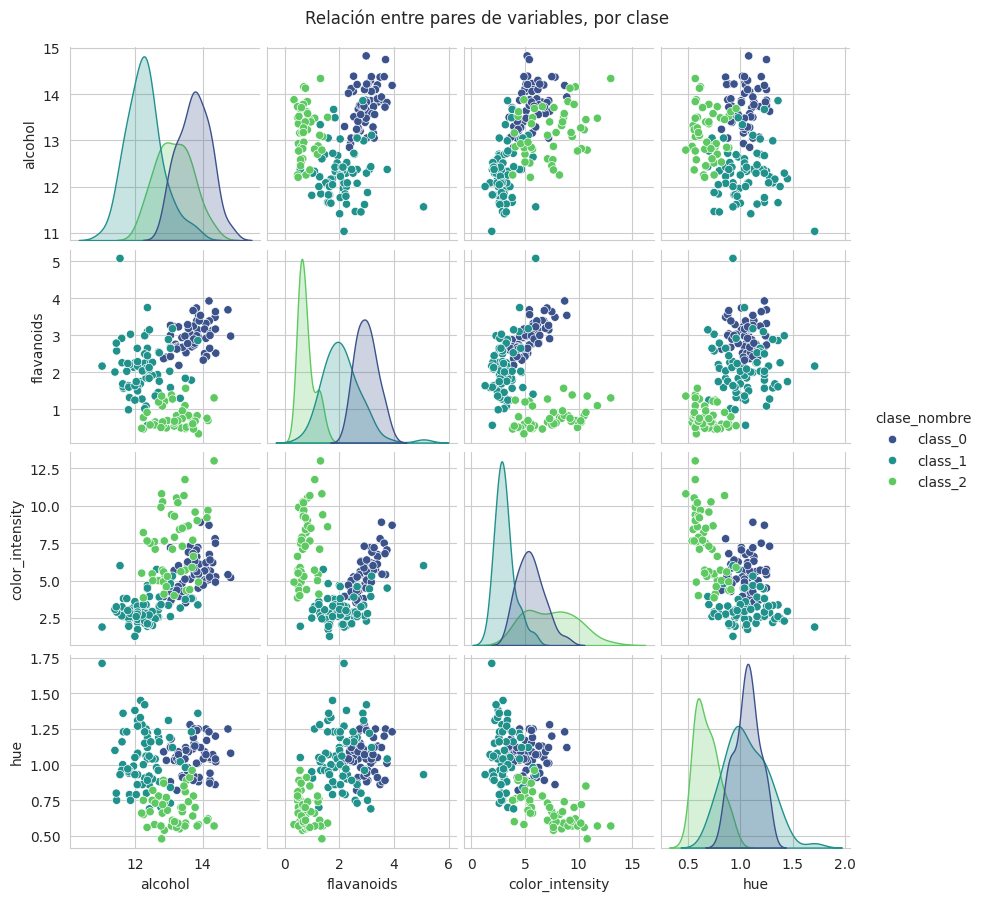

In [ ]:
subset = ["alcohol", "flavanoids", "color_intensity", "hue", "clase_nombre"]
sns.pairplot(df[subset], hue="clase_nombre", palette="viridis", diag_kind="kde", height=2.2)
plt.suptitle("Relación entre pares de variables, por clase", y=1.02)
plt.show()

**Lectura:** en un `pairplot`, cada punto es una muestra y cada color una clase. Cuando los colores forman "islas" separadas (como con `flavanoids` vs `color_intensity`), esa combinación de variables es muy útil para distinguir clases — es justamente lo que un modelo de clasificación intentará aprender.

## 4. Detección de valores atípicos (outliers)

Usamos el método del **rango intercuartílico (IQR)**: un valor es atípico si cae por debajo de `Q1 - 1.5*IQR` o por encima de `Q3 + 1.5*IQR`.

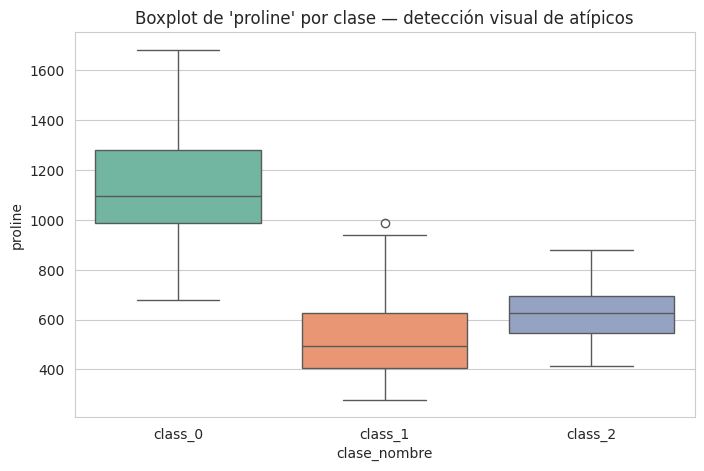

In [ ]:
plt.figure()
sns.boxplot(data=df, x="clase_nombre", y="proline", hue="clase_nombre", palette="Set2", legend=False)
plt.title("Boxplot de 'proline' por clase — detección visual de atípicos")
plt.show()

In [ ]:
def detectar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (serie < limite_inf) | (serie > limite_sup)

outliers_totales = pd.Series(False, index=df.index)
for col in datos.feature_names:
    outliers_totales |= detectar_outliers_iqr(df[col])

print(f"Muestras con al menos un valor atípico: {outliers_totales.sum()} de {len(df)}")
df[outliers_totales].head()

Muestras con al menos un valor atípico: 17 de 178


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase,clase_nombre
25,13.05,2.05,3.22,25.0,124.0,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830.0,0,class_0
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1,class_1
69,12.21,1.19,1.75,16.8,151.0,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718.0,1,class_1
73,12.99,1.67,2.60,30.0,139.0,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985.0,1,class_1
78,12.33,0.99,1.95,14.8,136.0,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750.0,1,class_1


**Nota pedagógica:** detectar un atípico NO significa eliminarlo automáticamente. Puede ser un error de medición (se corrige o se elimina) o una muestra real pero extrema (se conserva, y en ese caso es una señal para usar modelos o escaladores robustos a atípicos).

## 5. Valores faltantes

El dataset Wine no trae valores faltantes de forma nativa, así que introducimos algunos artificialmente (como ocurre en datasets reales) para practicar cómo detectarlos e imputarlos.

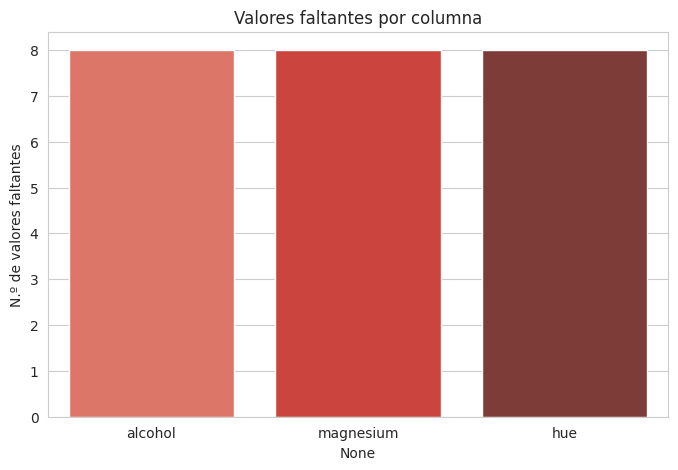

In [ ]:
df_con_nulos = df.copy()
rng = np.random.default_rng(42)
for col in ["alcohol", "magnesium", "hue"]:
    idx_nulos = rng.choice(df_con_nulos.index, size=8, replace=False)
    df_con_nulos.loc[idx_nulos, col] = np.nan

faltantes = df_con_nulos[datos.feature_names].isna().sum()
faltantes = faltantes[faltantes > 0]

plt.figure()
sns.barplot(x=faltantes.index, y=faltantes.values, hue=faltantes.index, palette="Reds_d", legend=False)
plt.title("Valores faltantes por columna")
plt.ylabel("N.º de valores faltantes")
plt.show()

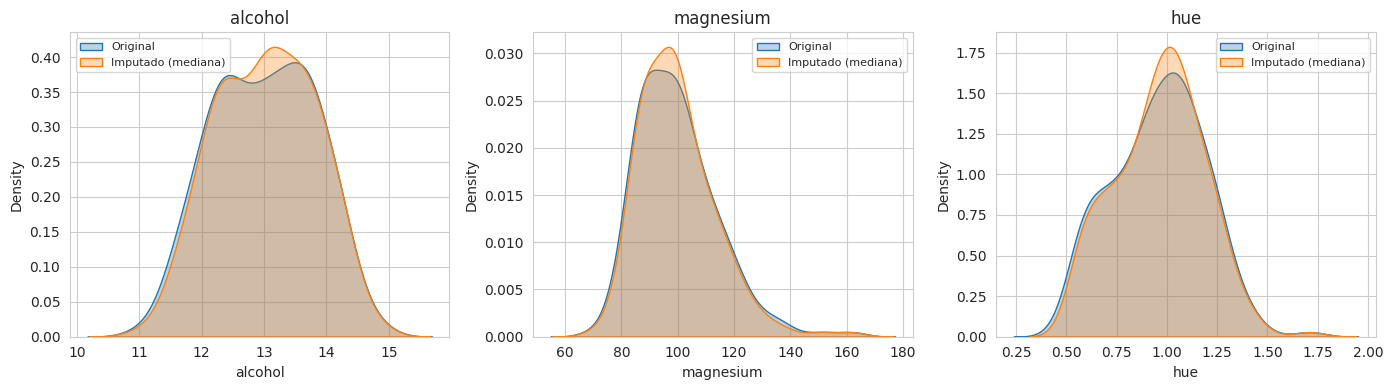

Valores faltantes tras la imputación: 0


In [ ]:
imputador = SimpleImputer(strategy="median")
columnas_con_nulos = list(faltantes.index)

antes = df_con_nulos[columnas_con_nulos].copy()
df_imputado = df_con_nulos.copy()
df_imputado[columnas_con_nulos] = imputador.fit_transform(df_con_nulos[columnas_con_nulos])

fig, ejes = plt.subplots(1, len(columnas_con_nulos), figsize=(14, 4))
for ax, col in zip(ejes, columnas_con_nulos):
    sns.kdeplot(df[col], ax=ax, label="Original", fill=True, alpha=0.3)
    sns.kdeplot(df_imputado[col], ax=ax, label="Imputado (mediana)", fill=True, alpha=0.3)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Valores faltantes tras la imputación:", df_imputado[columnas_con_nulos].isna().sum().sum())

**Lectura:** la distribución imputada (naranja) se mantiene muy parecida a la original (azul) porque usamos la mediana, que es robusta a atípicos. Si hubiéramos usado la media con datos muy sesgados, la distribución imputada podría deformarse más.

## 6. Codificación de variables categóricas

El dataset Wine es puramente numérico, así que creamos una columna categórica sintética (región de origen) para mostrar las dos técnicas de codificación más usadas.

In [ ]:
regiones = rng.choice(["Valle Norte", "Valle Central", "Valle Sur"], size=len(df))
df_cat = df.copy()
df_cat["region"] = regiones
df_cat[["region"]].value_counts()

,count
region,
Valle Sur,63
Valle Central,62
Valle Norte,53


In [ ]:
# --- Label Encoding: asigna un entero a cada categoría (útil cuando SÍ hay orden, ej. "bajo/medio/alto") ---
le = LabelEncoder()
df_cat["region_label"] = le.fit_transform(df_cat["region"])

# --- One-Hot Encoding: crea una columna binaria por categoría (recomendado cuando NO hay orden) ---
ohe = OneHotEncoder(sparse_output=False)
codificado = ohe.fit_transform(df_cat[["region"]])
df_ohe = pd.DataFrame(codificado, columns=ohe.get_feature_names_out(["region"]))

print("Label Encoding:")
display(df_cat[["region", "region_label"]].drop_duplicates())
print("\nOne-Hot Encoding:")
display(pd.concat([df_cat[["region"]], df_ohe], axis=1).drop_duplicates())

Label Encoding:


,region,region_label
0,Valle Sur,2
1,Valle Central,0
6,Valle Norte,1



One-Hot Encoding:


,region,region_Valle Central,region_Valle Norte,region_Valle Sur
0,Valle Sur,0.0,0.0,1.0
1,Valle Central,1.0,0.0,0.0
6,Valle Norte,0.0,1.0,0.0


**Cuándo usar cada una:**
- **Label Encoding**: rápido, pero introduce una relación de orden artificial (0 < 1 < 2) que puede confundir a modelos lineales. Apropiado solo si la categoría es realmente ordinal.
- **One-Hot Encoding**: no introduce orden falso, pero aumenta el número de columnas. Es la opción por defecto para variables categóricas nominales, especialmente en redes neuronales.

## 7. Escalado de características

Las redes neuronales (y muchos algoritmos de ML) convergen mejor y más rápido cuando las variables están en escalas comparables.

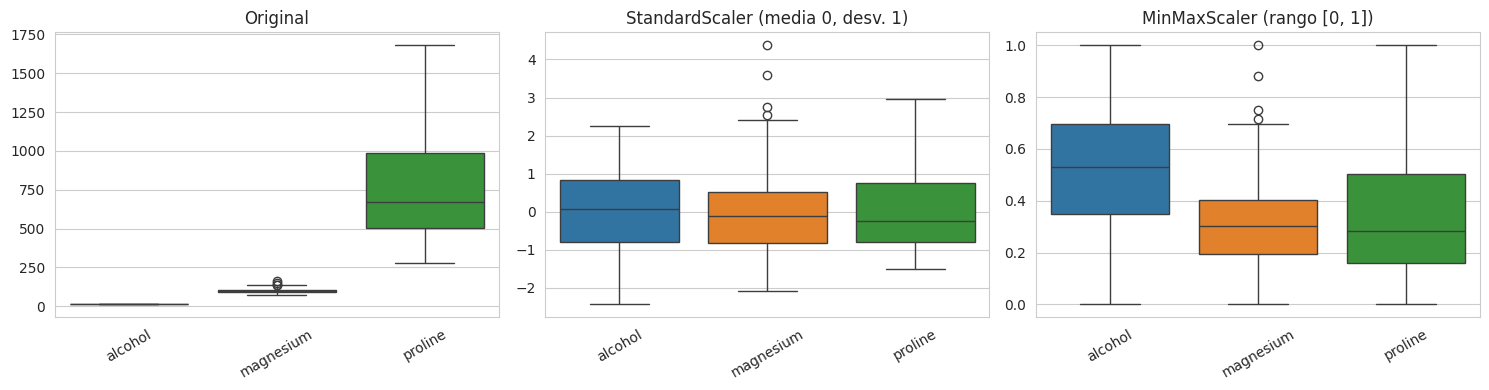

In [ ]:
escalador_std = StandardScaler()
escalador_minmax = MinMaxScaler()

X = df[datos.feature_names]
X_std = pd.DataFrame(escalador_std.fit_transform(X), columns=X.columns)
X_minmax = pd.DataFrame(escalador_minmax.fit_transform(X), columns=X.columns)

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, titulo in zip(
    ejes, [X, X_std, X_minmax],
    ["Original", "StandardScaler (media 0, desv. 1)", "MinMaxScaler (rango [0, 1])"]
):
    sns.boxplot(data=data[["alcohol", "magnesium", "proline"]], ax=ax)
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Lectura:** en el gráfico "Original", `proline` (cientos) domina visualmente sobre `hue` (unidades) — un modelo basado en distancias (o una red neuronal sin escalar) le daría más peso del que le corresponde solo por su magnitud numérica. Tras escalar, todas las variables ocupan rangos comparables.

- **StandardScaler**: recomendado por defecto para redes neuronales y modelos lineales.
- **MinMaxScaler**: útil cuando se necesita un rango fijo y conocido (ej. entradas de imágenes en [0, 1]).

## 8. División en entrenamiento y prueba (train/test split)

Siempre se separa una porción de los datos que el modelo **nunca** ve durante el entrenamiento, para evaluar su capacidad de generalización de forma honesta.

Entrenamiento: 142 muestras
Prueba: 36 muestras


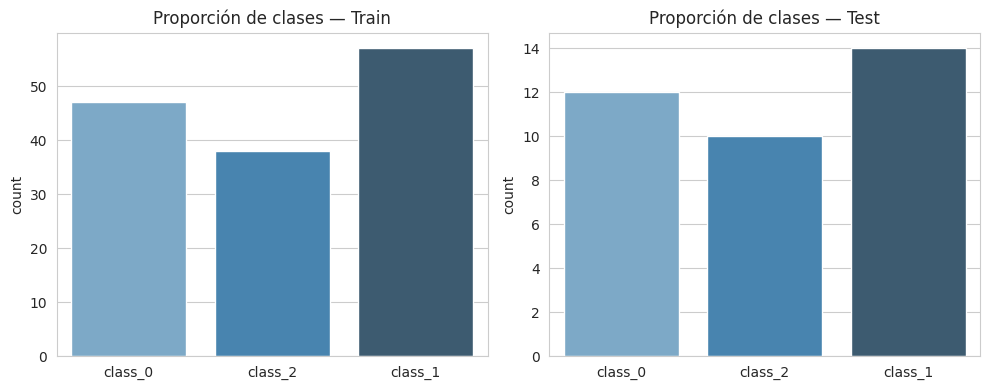

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_std, df["clase"], test_size=0.2, random_state=42, stratify=df["clase"]
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, titulo in zip(ejes, [y_train, y_test], ["Train", "Test"]):
    sns.countplot(x=y.map(dict(enumerate(datos.target_names))), hue=y.map(dict(enumerate(datos.target_names))),
                  ax=ax, palette="Blues_d", legend=False)
    ax.set_title(f"Proporción de clases — {titulo}")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Lectura:** gracias a `stratify=df["clase"]`, la proporción de cada clase es casi idéntica en train y test — evita que, por mala suerte del muestreo aleatorio, una clase quede subrepresentada en la partición de prueba.

## 9. Resumen — checklist de preprocesamiento

| Paso | ¿Por qué importa? | Herramienta usada |
|---|---|---|
| Explorar tipos y nulos | Detectar problemas antes de modelar | `df.info()`, `df.describe()` |
| Visualizar distribuciones | Entender la forma de los datos y posibles sesgos | `histplot`, `pairplot` |
| Detectar atípicos | Decidir si corregir, eliminar o conservar | Regla IQR + `boxplot` |
| Imputar faltantes | Los modelos no aceptan `NaN` | `SimpleImputer` |
| Codificar categóricas | Los modelos requieren entradas numéricas | `OneHotEncoder`, `LabelEncoder` |
| Escalar variables | Acelera y estabiliza el entrenamiento | `StandardScaler`, `MinMaxScaler` |
| Dividir train/test | Evaluar generalización de forma honesta | `train_test_split` con `stratify` |

Este flujo es el punto de partida de **todos** los notebooks siguientes: perceptrón/MLP, CNN, RNN, ajuste de hiperparámetros y evaluación de modelos.
